# Transistores NMOS y PMOS aislados: punto de operación y ruido

Este notebook estudia un NMOS y un PMOS por separado con el modelo de primer orden (Level 1) de `razavi_cmos.lib`: calcula su punto de operación, sus parámetros de pequeña señal, sus capacitancias y su ruido, y lo compara con ngspice. Todos los cálculos están en el módulo `razavi_mos.py` (la misma copia vive en `ngspice/Razavi` y en `LTspice/Razavi`), que tiene cuatro funciones:

| Función | Qué hace |
|---|---|
| `leer_parametros_modelo(simulador, modelo)` | Lee los parámetros de un `.MODEL` de `razavi_cmos.lib`. El simulador (`"ngspice"` o `"ltspice"`) elige la librería y la fórmula del ruido flicker, porque el `kf` de cada una es distinto |
| `calcular_transistor(params, tipo, VGS, VDS, VSB, W, L)` | Punto de operación, conductancias, capacitancias, ruido térmico y esquina del flicker. Regresa un objeto con atributos (`nch.gm`, `nch.cgg`, ...) |
| `tabla_transistores(...)` | Imprime los parámetros de uno o varios transistores en una tabla |
| `ruido_vs_frecuencia(transistor, f)` | Densidad espectral de ruido en un vector de frecuencias |

**Convención de signos.** Todos los voltajes y corrientes, de entrada y de salida, son **magnitudes positivas**, también en el PMOS: `VGS = 0.9` significa $|V_{GS}|=0.9$ V. LTspice (y ngspice) reportan el PMOS con signo negativo en $I_D$, $V_{GS}$, $V_{DS}$, $V_{TH}$ y $V_{DSat}$; aquí no. En este notebook se comparan magnitudes.

**Convención del código.** Las funciones están en `razavi_mos.py`, con sus ecuaciones comentadas; el notebook solo las usa.

## Ecuaciones que implementa el módulo

**Umbral y sobreexcitación** (efecto de cuerpo):
$$V_{TH}=V_{TH0}+\gamma\left(\sqrt{\phi+V_{SB}}-\sqrt{\phi}\right), \qquad V_{ov}=V_{GS}-V_{TH}, \qquad \beta=k_p\frac{W}{L}.$$

**Corriente y conductancias** (todas con magnitudes):

| Región | Condición | $I_D$ | $g_m$ | $g_{ds}$ |
|---|---|---|---|---|
| Corte | $V_{ov}\le 0$ | $0$ | $0$ | $0$ |
| Triodo | $V_{DS}<V_{ov}$ | $\beta(1+\lambda V_{DS})\,V_{DS}\left(V_{ov}-\tfrac{V_{DS}}{2}\right)$ | $\beta(1+\lambda V_{DS})V_{DS}$ | $\beta(1+\lambda V_{DS})(V_{ov}-V_{DS})+\beta\lambda V_{DS}\left(V_{ov}-\tfrac{V_{DS}}{2}\right)$ |
| Saturación | $V_{DS}\ge V_{ov}$ | $\tfrac12\beta(1+\lambda V_{DS})V_{ov}^2$ | $\beta(1+\lambda V_{DS})V_{ov}$ | $\tfrac12\beta\lambda V_{ov}^2$ |

con $g_{mb}=g_m\,\dfrac{\gamma}{2\sqrt{\phi+V_{SB}}}$.

**Capacitancias.** Las intrínsecas de compuerta usan el modelo de Meyer, con $C=C_{ox}WL$ y $C_{ox}=\epsilon_{ox}/t_{ox}$; las de traslape son $C_{GSO}W$ y $C_{GDO}W$; las de unión son $C_{bd}=C_{bs}=C_jA+C_{jsw}P$ con $A=W\,w_d$ y $P=2W+2w_d$ (la regla del subcircuito de la librería, con $w_d=0.48\,\mu$m). Los totales de cada nodo son

$$C_{gg}=C_{gs}+C_{gd}+C_{gb},\qquad C_{dd}=C_{gd}+C_{bd},\qquad C_{ss}=C_{gs}+C_{bs},$$

donde $C_{gs}$, $C_{gd}$ y $C_{gb}$ incluyen el traslape.

**Relaciones útiles:**
$$A_v=\frac{g_m}{g_{ds}}\ \text{(ganancia intrínseca)},\qquad f_T\approx\frac{g_m}{2\pi C_{gg}}.$$

**Ruido.** El térmico del canal es $S_{I_D,th}=4kT\cdot\tfrac23 g_m$ en los dos simuladores. El flicker es

| | $S_{I_D,fl}(f)$ |
|---|---|
| ngspice | $\dfrac{K_F\,I_D^{A_F}}{f\,WL\,C_{ox}^2}$ |
| LTspice | $\dfrac{K_F\,g_m^2}{f\,WL\,C_{ox}}$ (verificada con $A_F=1$) |

y la esquina es la frecuencia en la que ambos se igualan, $f_c=S_{I_D,fl}(1\,\text{Hz})/S_{I_D,th}$. Referido a la entrada, $S_{V_{in}}=S_{I_D}/g_m^2$.

## Imports y simulador

La variable `SIMULADOR` elige la librería (`razavi_cmos.lib` de ngspice o de LTspice) y, con ella, el valor de `kf` y la fórmula del flicker. Para comparar contra los `.raw` de este notebook se mantiene en `"ngspice"`.

In [1]:
# Paso 1: importar las librerias
import logging
import re

import numpy as np                  # calculos numericos
import matplotlib.pyplot as plt     # graficas

from spicelib import RawRead        # lee los archivos .raw
from prettytable import PrettyTable           # tablas de resultados
from si_prefix import si_format as num2eng   # prefijos de ingenieria (n, u, k, M...)

import razavi_mos as rm             # las cuatro funciones de este notebook (razavi_mos.py)

# Paso 2: estilo de las graficas (Arial si esta instalada; si no, la siguiente fuente de la lista)
logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'Liberation Sans', 'DejaVu Sans']

C_HAND = "#2a78d6"     # calculo a mano
C_SIM = "#eb6834"      # simulador
C_AUX = "#52514e"      # lineas auxiliares

# Paso 3: simulador cuyos parametros y formula de ruido se usan: "ngspice" o "ltspice"
SIMULADOR = "ngspice"

## 1. Parámetros del modelo (`leer_parametros_modelo`)

Se leen los `.MODEL` `nch` y `pch` de la librería del simulador elegido. La función no interpreta los subcircuitos (`xnch`, `xpch`): solo los `.MODEL`. Los parámetros que la librería no declara toman el valor por omisión de SPICE.

In [2]:
# Paso 1: leer los parametros de los modelos NMOS y PMOS del simulador elegido
par_nch = rm.leer_parametros_modelo(SIMULADOR, "nch")
par_pch = rm.leer_parametros_modelo(SIMULADOR, "pch")
print("Libreria leida:", par_nch["lib"])

# Paso 2: tabla con los parametros (unidades SI)
claves = ["kp", "vto", "gamma", "lambda_", "phi", "tox", "cgso", "cgdo", "cj", "cjsw", "mj", "mjsw", "kf", "af", "rd", "rs"]
myTable = PrettyTable(["Parametro", "nch", "pch"])
for clave in claves:
    myTable.add_row([clave, f"{par_nch[clave]:.4g}", f"{par_pch[clave]:.4g}"])
myTable.align["Parametro"] = "l"
print(myTable)

# Paso 3: el kf de cada simulador es distinto porque la formula del flicker es distinta
myTable = PrettyTable(["Simulador", "kf nch", "kf pch"])
for sim_i in ["ngspice", "ltspice"]:
    myTable.add_row([sim_i, f"{rm.leer_parametros_modelo(sim_i, 'nch')['kf']:.3g}", f"{rm.leer_parametros_modelo(sim_i, 'pch')['kf']:.3g}"])
print("\nkf en cada libreria")
print(myTable)

Libreria leida: /home/claude/torr250/analog-icdesign-opentools/ngspice/Razavi/razavi_cmos.lib
+-----------+-----------+-----------+
| Parametro |    nch    |    pch    |
+-----------+-----------+-----------+
| kp        |   0.0001  |   5e-05   |
| vto       |    0.4    |    -0.4   |
| gamma     |    0.4    |    0.4    |
| lambda_   |    0.1    |    0.1    |
| phi       |    0.3    |    0.3    |
| tox       |   4e-09   |   4e-09   |
| cgso      | 9.548e-10 | 9.548e-10 |
| cgdo      | 9.548e-10 | 9.548e-10 |
| cj        |  0.000981 |  0.000981 |
| cjsw      |  1.19e-10 |  1.19e-10 |
| mj        |     0     |     0     |
| mjsw      |     0     |     0     |
| kf        |   3e-29   |  3.5e-30  |
| af        |     1     |     1     |
| rd        |     0     |     0     |
| rs        |     0     |     0     |
+-----------+-----------+-----------+

kf en cada libreria
+-----------+----------+---------+
| Simulador |  kf nch  |  kf pch |
+-----------+----------+---------+
|  ngspice  |  3e-29

## 2. Punto de operación y parámetros de pequeña señal (`calcular_transistor`, `tabla_transistores`)

Se calcula el NMOS y el PMOS, ambos con $W=1\,\mu$m y $L=0.18\,\mu$m, con $V_{GS}=V_{DS}=0.9$ V y $V_{SB}=0$ (como en `DC_Sweep_Razavi`). Como $k_p$ del PMOS es la mitad que la del NMOS, el PMOS tiene la mitad de corriente y de $g_m$. `calcular_transistor` regresa un objeto cuyos atributos son las cantidades calculadas; `tabla_transistores` las imprime juntas.

In [3]:
# Paso 1: polarizacion y geometria (magnitudes positivas, tambien para el PMOS)
VGS, VDS, VSB = 0.9, 0.9, 0.0     # V
L = 0.18e-6                       # m
W_n = 1e-6                        # m, NMOS
W_p = 1e-6                        # m, PMOS

# Paso 2: calcular cada transistor con su modelo y su tipo ("n" o "p")
nch = rm.calcular_transistor(par_nch, "n", VGS, VDS, VSB, W_n, L)
pch = rm.calcular_transistor(par_pch, "p", VGS, VDS, VSB, W_p, L)

# Paso 3: imprimir el punto de operacion, las capacitancias y el ruido en una tabla
rm.tabla_transistores(nch, pch, nombres=["NMOS (W = 1 um)", "PMOS (W = 1 um)"])

+-------------------------------+-----------------+-----------------+
| Parametro                     | NMOS (W = 1 um) | PMOS (W = 1 um) |
+-------------------------------+-----------------+-----------------+
| Region                        |    saturacion   |    saturacion   |
| VGS [V]                       |    900.000 m    |    900.000 m    |
| VDS [V]                       |    900.000 m    |    900.000 m    |
| VSB [V]                       |      0.000      |      0.000      |
| VTH [V]                       |    400.000 m    |    400.000 m    |
| Vov = VGS - VTH [V]           |    500.000 m    |    500.000 m    |
| VDSat [V]                     |    500.000 m    |    500.000 m    |
| ID [A]                        |     75.694 µ    |     37.847 µ    |
| gm [S]                        |    302.778 µ    |    151.389 µ    |
| gds [S]                       |     6.944 µ     |     3.472 µ     |
| gmb [S]                       |    110.559 µ    |     55.279 µ    |
| Cgs (total) [F]   

Parametro,NMOS (W = 1 um),PMOS (W = 1 um)
Region,saturacion,saturacion
VGS [V],900.000 m,900.000 m
VDS [V],900.000 m,900.000 m
VSB [V],0.000,0.000
VTH [V],400.000 m,400.000 m
Vov = VGS - VTH [V],500.000 m,500.000 m
VDSat [V],500.000 m,500.000 m
ID [A],75.694 µ,37.847 µ
gm [S],302.778 µ,151.389 µ
gds [S],6.944 µ,3.472 µ


## 3. Ganancia intrínseca y frecuencia de transición

Con los atributos del objeto se calculan relaciones como

$$A_v=\frac{g_m}{g_{ds}}, \qquad f_T=\frac{g_m}{2\pi C_{gg}}, \qquad \frac{g_m}{I_D}.$$

$C_{gg}$ es la capacitancia total del nodo de compuerta (con $C_{gs}$, $C_{gd}$ y $C_{gb}$ incluyendo el traslape), así que $f_T$ es una estimación conservadora de la frecuencia de ganancia unitaria de corriente.

In [4]:
# Paso 1: ganancia intrinseca, frecuencia de transicion y eficiencia gm/Id de cada transistor
Av_n = nch.gm / nch.gds                         # V/V
Av_p = pch.gm / pch.gds
ft_n = nch.gm / (2 * np.pi * nch.cgg)           # Hz
ft_p = pch.gm / (2 * np.pi * pch.cgg)
gmid_n = nch.gm / nch.id                        # 1/V
gmid_p = pch.gm / pch.id

# Paso 2: tabla de resultados
myTable = PrettyTable(["Cantidad", "NMOS", "PMOS"])
myTable.add_row(["Av = gm / gds [V/V]", f"{Av_n:.2f}", f"{Av_p:.2f}"])
myTable.add_row(["Av [dB]", f"{20 * np.log10(Av_n):.2f}", f"{20 * np.log10(Av_p):.2f}"])
myTable.add_row(["ft = gm / (2 pi Cgg) [Hz]", num2eng(ft_n) + "Hz", num2eng(ft_p) + "Hz"])
myTable.add_row(["gm / Id [1/V]", f"{gmid_n:.2f}", f"{gmid_p:.2f}"])
myTable.add_row(["Cgg [F]", num2eng(nch.cgg) + "F", num2eng(pch.cgg) + "F"])
myTable.add_row(["Cdd [F]", num2eng(nch.cdd) + "F", num2eng(pch.cdd) + "F"])
myTable.add_row(["Css [F]", num2eng(nch.css) + "F", num2eng(pch.css) + "F"])
myTable.align["Cantidad"] = "l"
print(myTable)

+---------------------------+----------+---------+
| Cantidad                  |   NMOS   |   PMOS  |
+---------------------------+----------+---------+
| Av = gm / gds [V/V]       |  43.60   |  43.60  |
| Av [dB]                   |  32.79   |  32.79  |
| ft = gm / (2 pi Cgg) [Hz] | 16.4 GHz | 8.2 GHz |
| gm / Id [1/V]             |   4.00   |   4.00  |
| Cgg [F]                   |  2.9 fF  |  2.9 fF |
| Cdd [F]                   |  1.8 fF  |  1.8 fF |
| Css [F]                   |  2.8 fF  |  2.8 fF |
+---------------------------+----------+---------+


### Fuera de saturación

El mismo cálculo funciona en cualquier región. Aquí se baja $V_{DS}$ del NMOS a 0.1 V (triodo) y se compara con saturación; `tabla_transistores` imprime un aviso porque el ruido térmico $4kT\cdot\frac23 g_m$ **no es físico en triodo** (ver *Qué hay que vigilar*).

In [5]:
# Paso 1: el mismo NMOS con VDS = 0.9 V (saturacion) y con VDS = 0.1 V (triodo)
nch_sat = rm.calcular_transistor(par_nch, "n", 0.9, 0.9, 0.0, W_n, L)
nch_tri = rm.calcular_transistor(par_nch, "n", 0.9, 0.1, 0.0, W_n, L)

# Paso 2: tabla de ambos; la leyenda final advierte sobre el ruido termico en triodo
rm.tabla_transistores(nch_sat, nch_tri, nombres=["NMOS, VDS = 0.9 V", "NMOS, VDS = 0.1 V"])

+-------------------------------+-------------------+-------------------+
| Parametro                     | NMOS, VDS = 0.9 V | NMOS, VDS = 0.1 V |
+-------------------------------+-------------------+-------------------+
| Region                        |     saturacion    |       triodo      |
| VGS [V]                       |     900.000 m     |     900.000 m     |
| VDS [V]                       |     900.000 m     |     100.000 m     |
| VSB [V]                       |       0.000       |       0.000       |
| VTH [V]                       |     400.000 m     |     400.000 m     |
| Vov = VGS - VTH [V]           |     500.000 m     |     500.000 m     |
| VDSat [V]                     |     500.000 m     |     500.000 m     |
| ID [A]                        |      75.694 µ     |      25.250 µ     |
| gm [S]                        |     302.778 µ     |      56.111 µ     |
| gds [S]                       |      6.944 µ      |     226.944 µ     |
| gmb [S]                       |     

Parametro,"NMOS, VDS = 0.9 V","NMOS, VDS = 0.1 V"
Region,saturacion,triodo
VGS [V],900.000 m,900.000 m
VDS [V],900.000 m,100.000 m
VSB [V],0.000,0.000
VTH [V],400.000 m,400.000 m
Vov = VGS - VTH [V],500.000 m,500.000 m
VDSat [V],500.000 m,500.000 m
ID [A],75.694 µ,25.250 µ
gm [S],302.778 µ,56.111 µ
gds [S],6.944 µ,226.944 µ


## 4. Comparación del punto de operación con ngspice

`DC_Sweep_Razavi.log` guarda el `.op` de ngspice de un NMOS y un PMOS, ambos con $W=1\,\mu$m y $L=0.18\,\mu$m, con $V_{GS}=V_{DS}=0.9$ V. Se calculan los mismos dos transistores con `calcular_transistor` y se comparan magnitudes (ngspice reporta el PMOS con signo negativo en $I_D$, $V_{on}$ y $V_{dsat}$; se usa el valor absoluto). Las capacitancias que reporta ngspice (`cgs`, `cgd`, `cgb`) incluyen el traslape, igual que las del módulo.

In [6]:
# Paso 1: leer del log de ngspice el .op del NMOS (xu1) y del PMOS (xu2)
log_txt = open("DC_Sweep_Razavi.log", encoding="utf-8", errors="ignore").read()
ref = {(disp, par): float(val) for disp, par, val in re.findall(r"^@m\.(xu\d)\.m1\[(\w+)\]\s*=\s*([-+0-9.eE]+)", log_txt, flags=re.M)}

# Paso 2: calcular los mismos transistores (W = 1 um los dos, como en DC_Sweep_Razavi.cir)
nch_dc = rm.calcular_transistor(par_nch, "n", 0.9, 0.9, 0.0, 1e-6, 0.18e-6)
pch_dc = rm.calcular_transistor(par_pch, "p", 0.9, 0.9, 0.0, 1e-6, 0.18e-6)

# Paso 3: comparar parametro por parametro (atributo del objeto, nombre en ngspice)
pares = [("id", "id"), ("gm", "gm"), ("gds", "gds"), ("gmb", "gmbs"), ("vth", "von"), ("vdsat", "vdsat"),
         ("cgs", "cgs"), ("cgd", "cgd"), ("cgb", "cgb"), ("cbd", "cbd"), ("cbs", "cbs")]
myTable = PrettyTable(["Parametro", "NMOS funcion", "NMOS ngspice", "Error NMOS", "PMOS funcion", "PMOS ngspice", "Error PMOS"])
for atributo, nombre_ng in pares:
    fila = [atributo]
    for t, disp in [(nch_dc, "xu1"), (pch_dc, "xu2")]:
        valor = getattr(t, atributo)
        valor_ng = abs(ref[(disp, nombre_ng)])
        error = "-" if valor_ng == 0 else f"{(valor / valor_ng - 1) * 100:+.2e} %"
        fila += [f"{valor:.4e}", f"{valor_ng:.4e}", error]
    myTable.add_row(fila)
print(myTable)

+-----------+--------------+--------------+-------------+--------------+--------------+-------------+
| Parametro | NMOS funcion | NMOS ngspice |  Error NMOS | PMOS funcion | PMOS ngspice |  Error PMOS |
+-----------+--------------+--------------+-------------+--------------+--------------+-------------+
|     id    |  7.5694e-05  |  7.5694e-05  | -7.34e-06 % |  3.7847e-05  |  3.7847e-05  | +5.87e-06 % |
|     gm    |  3.0278e-04  |  3.0278e-04  | -7.34e-06 % |  1.5139e-04  |  1.5139e-04  | -7.34e-06 % |
|    gds    |  6.9444e-06  |  6.9444e-06  | +6.40e-06 % |  3.4722e-06  |  3.4722e-06  | +6.40e-06 % |
|    gmb    |  1.1056e-04  |  1.1056e-04  | +1.13e-05 % |  5.5279e-05  |  5.5279e-05  | -6.75e-06 % |
|    vth    |  4.0000e-01  |  4.0000e-01  | +0.00e+00 % |  4.0000e-01  |  4.0000e-01  | +0.00e+00 % |
|   vdsat   |  5.0000e-01  |  5.0000e-01  | +0.00e+00 % |  5.0000e-01  |  5.0000e-01  | +0.00e+00 % |
|    cgs    |  1.9907e-15  |  1.9907e-15  | +7.03e-06 % |  1.9907e-15  |  1.9907e-

## 5. Ruido en frecuencia (`ruido_vs_frecuencia`)

La función recibe el objeto del transistor y un vector de frecuencias y regresa las densidades espectrales (corriente del canal, térmica y flicker; referida a la entrada y a la salida). Con carga ideal (inductor enorme, circuito A de los notebooks de ruido) es

$$S_{V_{in}}(f)=\frac{S_{I_D,th}+K/f}{g_m^2},\qquad K=S_{I_D,fl}(1\,\text{Hz}).$$

La gráfica muestra el ruido referido a la entrada del NMOS y del PMOS, el piso térmico, la esquina $f_c$ y, como referencia, los puntos de la simulación de ngspice de cada transistor (`.noise` de 1 Hz a 100 MHz, 20 puntos por década).

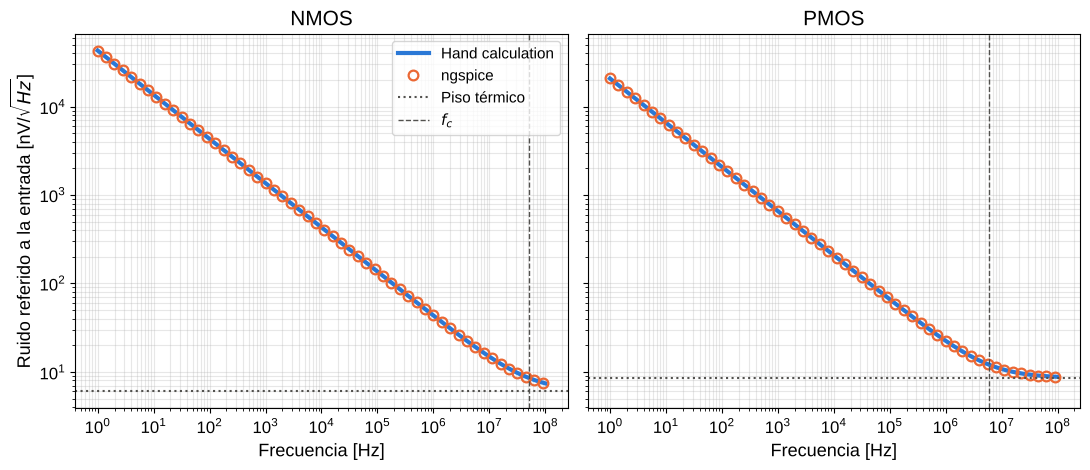

+--------------------------+----------+---------+
|                          |   NMOS   |   PMOS  |
+--------------------------+----------+---------+
|  Piso térmico [nV/rtHz]  |   6.04   |   8.54  |
| Flicker a 1 Hz [uV/rtHz] |  42.97   |  20.76  |
|        Esquina fc        | 50.6 MHz | 5.9 MHz |
+--------------------------+----------+---------+


In [7]:
# Paso 1: vector de frecuencias, el mismo de .noise dec 20 1 100Meg (161 puntos de 1 Hz a 100 MHz)
f = np.logspace(0, 8, 161)

# Paso 2: respuesta de ruido del NMOS y del PMOS con carga ideal
ruido_n = rm.ruido_vs_frecuencia(nch, f)
ruido_p = rm.ruido_vs_frecuencia(pch, f)

# Paso 3: nombres de las trazas y archivos de la simulacion de cada transistor (circuito A)
if SIMULADOR == "ngspice":
    traza_in, traza_out, dialecto = "inoise_spectrum", "onoise_spectrum", "ngspice"
    archivos_A = {"NMOS": "Noise_A.raw", "PMOS": "Noise_PA.raw"}
else:
    traza_in, traza_out, dialecto = "v(inoise)", "v(onoise)", None
    archivos_A = {"NMOS": "Noise_A.raw", "PMOS": "Noise_PA.raw"}

# Paso 4: leer los resultados de la simulacion si existen (V/rtHz -> V^2/Hz)
sim_A = {}
for nombre, archivo in archivos_A.items():
    try:
        raw = RawRead(archivo, dialect=dialecto)
        sim_A[nombre] = np.abs(raw.get_trace(traza_in).get_wave(0)).astype(float) ** 2
    except FileNotFoundError:
        print(f"No hay {archivo}: se grafica solo el calculo a mano del {nombre}")

# Paso 5: grafica del ruido referido a la entrada (nV/rtHz) en ejes log-log
fig, axes = plt.subplots(1, 2, figsize=(11, 4.8), sharey=True)
for ax, nombre, t, r in zip(axes, ["NMOS", "PMOS"], [nch, pch], [ruido_n, ruido_p]):
    ax.loglog(f, np.sqrt(r["s_vin"]) * 1e9, linewidth=3, color=C_HAND, label="Hand calculation")
    if nombre in sim_A:
        ax.loglog(f[::3], np.sqrt(sim_A[nombre][::3]) * 1e9, 'o', markersize=7, mfc='none', mew=1.6, color=C_SIM, label=SIMULADOR)
    ax.axhline(np.sqrt(t.s_vin_th) * 1e9, color=C_AUX, linestyle=':', linewidth=1.5, label="Piso térmico")
    ax.axvline(t.f_corner, color=C_AUX, linestyle='--', linewidth=1, label=r"$f_c$")
    ax.set_title(nombre, fontsize=15, weight='normal')
    ax.set_xlabel("Frecuencia [Hz]", fontsize=13)
    ax.tick_params(labelsize=12)
    ax.grid(which='both', alpha=0.3)
axes[0].set_ylabel(r"Ruido referido a la entrada [nV/$\sqrt{Hz}$]", fontsize=13)
axes[0].legend(fontsize=11, loc="upper right")
fig.tight_layout()
plt.show()

# Paso 6: esquina y piso termico de cada transistor
myTable = PrettyTable(["", "NMOS", "PMOS"])
myTable.add_row(["Piso térmico [nV/rtHz]", f"{np.sqrt(nch.s_vin_th) * 1e9:.2f}", f"{np.sqrt(pch.s_vin_th) * 1e9:.2f}"])
myTable.add_row(["Flicker a 1 Hz [uV/rtHz]", f"{np.sqrt(nch.s_vin_fl_1Hz) * 1e6:.2f}", f"{np.sqrt(pch.s_vin_fl_1Hz) * 1e6:.2f}"])
myTable.add_row(["Esquina fc", num2eng(nch.f_corner) + "Hz", num2eng(pch.f_corner) + "Hz"])
print(myTable)

### Otras cargas: $R_D$ y resistencias serie

`ruido_vs_frecuencia` admite una resistencia de carga `RD` (circuito B: $R_D=10\,\text{k}\Omega$ entre el drenador y la alimentación, o a tierra en el PMOS), que suma su ruido térmico $4kT/R_D$ y cambia la conductancia del nodo de salida. El circuito C usa los modelos `nch_rs` y `pch_rs` ($r_d=r_s=200\,\Omega$); `calcular_transistor` obtiene el punto de operación intrínseco resolviendo la caída en $r_d$ y $r_s$, y `ruido_vs_frecuencia` resuelve la red de pequeña señal con las tres fuentes de ruido.

La celda calcula los tres circuitos del NMOS y del PMOS y los compara con las simulaciones disponibles: el error es el máximo en todo el barrido de $1$ Hz a $100$ MHz.

In [8]:
# Paso 1: transistores de los circuitos B (con RD) y C (con rd y rs)
RD = 10e3
VDD = 1.8
par_nch_rs = rm.leer_parametros_modelo(SIMULADOR, "nch_rs")
par_pch_rs = rm.leer_parametros_modelo(SIMULADOR, "pch_rs")

# Circuito B: el VDS depende de la corriente (VDS = VDD - Id*RD); se resuelve por iteracion de punto fijo
VDS_Bn = 0.9
VDS_Bp = 0.9
for _ in range(100):
    nch_B = rm.calcular_transistor(par_nch, "n", 0.9, VDS_Bn, 0.0, W_n, L)
    VDS_Bn = VDD - nch_B.id * RD
    pch_B = rm.calcular_transistor(par_pch, "p", 0.9, VDS_Bp, 0.0, W_p, L)
    VDS_Bp = VDD - pch_B.id * RD
nch_B = rm.calcular_transistor(par_nch, "n", 0.9, VDS_Bn, 0.0, W_n, L)
pch_B = rm.calcular_transistor(par_pch, "p", 0.9, VDS_Bp, 0.0, W_p, L)

# Circuito C: VGS y VDS externos de 0.9 V; la funcion resuelve el punto de operacion intrinseco
nch_C = rm.calcular_transistor(par_nch_rs, "n", 0.9, 0.9, 0.0, W_n, L)
pch_C = rm.calcular_transistor(par_pch_rs, "p", 0.9, 0.9, 0.0, W_p, L)

# Paso 2: respuesta de ruido de cada circuito
casos = {
    "NMOS A": (ruido_n, "Noise_A.raw"),
    "NMOS B": (rm.ruido_vs_frecuencia(nch_B, f, RD=RD), "Noise_B.raw"),
    "NMOS C": (rm.ruido_vs_frecuencia(nch_C, f), "Noise_C.raw"),
    "PMOS A": (ruido_p, "Noise_PA.raw"),
    "PMOS B": (rm.ruido_vs_frecuencia(pch_B, f, RD=RD), "Noise_PB.raw"),
    "PMOS C": (rm.ruido_vs_frecuencia(pch_C, f), "Noise_PC.raw"),
}

# Paso 3: comparar con la simulacion (si el archivo existe): error maximo de la densidad espectral referida a la entrada
myTable = PrettyTable(["Circuito", "Id [uA]", "Error max. Sin", "Error max. Sout"])
for nombre, (r, archivo) in casos.items():
    t = {"NMOS A": nch, "NMOS B": nch_B, "NMOS C": nch_C, "PMOS A": pch, "PMOS B": pch_B, "PMOS C": pch_C}[nombre]
    try:
        raw = RawRead(archivo, dialect=dialecto)
    except FileNotFoundError:
        myTable.add_row([nombre, f"{t.id * 1e6:.2f}", "sin simulacion", "sin simulacion"])
        continue
    S_in_sim = np.abs(raw.get_trace(traza_in).get_wave(0)).astype(float) ** 2
    S_out_sim = np.abs(raw.get_trace(traza_out).get_wave(0)).astype(float) ** 2
    err_in = np.max(np.abs(r["s_vin"] / S_in_sim - 1)) * 100
    err_out = "-" if nombre.endswith("C") else f"{np.max(np.abs(r['s_vout'] / S_out_sim - 1)) * 100:.2e} %"
    myTable.add_row([nombre, f"{t.id * 1e6:.2f}", f"{err_in:.2e} %", err_out])
print(myTable)

+----------+---------+----------------+-----------------+
| Circuito | Id [uA] | Error max. Sin | Error max. Sout |
+----------+---------+----------------+-----------------+
|  NMOS A  |  75.69  |   4.15e-04 %   |    5.08e-05 %   |
|  NMOS B  |  76.62  |   4.09e-04 %   |    2.75e-05 %   |
|  NMOS C  |  69.87  |   5.62e-04 %   |        -        |
|  PMOS A  |  37.85  |   1.60e-03 %   |    8.70e-05 %   |
|  PMOS B  |  39.60  |   1.47e-03 %   |    3.56e-05 %   |
|  PMOS C  |  36.31  |   1.84e-03 %   |        -        |
+----------+---------+----------------+-----------------+


## Qué hay que vigilar

* **Ruido térmico fuera de saturación.** Los simuladores usan $S_{I_D,th}=4kT\cdot\frac23 g_m$ en todas las regiones, y el módulo hace lo mismo para reproducirlos. En saturación es la expresión conocida, pero en **triodo** $g_m$ es pequeña ($g_m=\beta(1+\lambda V_{DS})V_{DS}\to0$) aunque el canal sea una resistencia $1/g_{ds}$ que sí genera ruido ($\approx4kT\,g_{ds}$ para $V_{DS}\to0$). El ruido térmico que muestra el modelo en triodo queda por debajo del real, y en corte vale cero. `tabla_transistores` imprime un aviso en esos casos.
* **Signos del PMOS.** El módulo trabaja con magnitudes positivas. LTspice y ngspice reportan el PMOS con $I_D$, $V_{GS}$, $V_{DS}$, $V_{TH}$ y $V_{DSat}$ negativos; al comparar contra un log hay que usar el valor absoluto. `VSB` también se ingresa positivo (polarización inversa del cuerpo); un `VSB` negativo no está soportado.
* **El `kf` depende del simulador.** La fórmula del flicker de ngspice y la de LTspice son distintas, y por eso `razavi_cmos.lib` tiene un `kf` distinto en cada carpeta. Hay que usar el mismo valor de `SIMULADOR` que el simulador con el que se compara. En LTspice solo se verificó la fórmula con $A_F=1$ y el módulo avisa si $A_F\ne1$.
* **El flicker de LTspice no depende de la polarización.** Referido a la entrada vale $K_F/(f\,WLC_{ox})$ siempre; el de ngspice sí depende de $I_D$, $g_m$ y $k_p$. Si se cambian $W$, $L$ o la polarización, el ruido flicker de los dos simuladores deja de coincidir aunque coincidiera en el punto de calibración.
* **Capacitancias.** `cgs`, `cgd` y `cgb` incluyen el traslape (ngspice las reporta así). LTspice reporta las intrínsecas (`Cgs`, `Cgd`, `Cgb`) y los traslapes (`Cgsov`, `Cgdov`, `Cgbov`) por separado; el módulo entrega ambas como `cgs_int` y `cgs_ov`. Con $m_j=m_{jsw}=0$ las de unión no dependen del voltaje; si se cambian, el módulo avisa y las calcula con polarización cero. $f_T=g_m/(2\pi C_{gg})$ usa la capacitancia total de compuerta, no solo $C_{gs}$.
* **Un caso borde de las capacitancias de compuerta.** En inversión débil ($-\phi/2<V_{GS}-V_{TH}<0$) con $V_{DS}=0$ exacto, ngspice reparte la capacitancia de Meyer entre $C_{gs}$ y $C_{gd}$ de otra manera y el módulo da una diferencia de hasta unos $0.1\,C_{ox}WL$. En el resto de los puntos de polarización probados (60 por tipo, 120 en total: corte, inversión débil, triodo, saturación, con y sin $V_{SB}$) coincide.
* **Geometría de las difusiones.** El área y el perímetro de las uniones se calculan con la regla del subcircuito de la librería ($A=W\,w_d$, $P=2W+2w_d$, $w_d=0.48\,\mu$m). El módulo no lee el subcircuito: si se cambia `wd` o la regla en la librería, hay que cambiarlo también en `razavi_mos.py` (argumento `wd` de `calcular_transistor`).
* **Resistencias serie.** Con `nch_rs` o `pch_rs` los parámetros de pequeña señal son los del transistor intrínseco, a sus voltajes internos (`vgs_i`, `vds_i`, `vsb_i`); `VGS` y `VDS` son los externos. En ese caso `ruido_vs_frecuencia` no incluye las capacitancias en el nodo de salida (solo se comparó el ruido referido a la entrada) y `RD` no se puede combinar con $r_d$ y $r_s$.
* **Validez del modelo.** El Level 1 no tiene corriente de subumbral, saturación de velocidad ni efectos de canal corto; para $L=0.18\,\mu$m LTspice avisa que la longitud y el ancho son menores a los recomendados. El módulo tampoco modela $V_{DS}<0$.
* **Temperatura.** El ruido térmico se calcula a 300.15 K (`temp = 27` °C, como las simulaciones). Para otra temperatura hay que pasar `T` a `calcular_transistor`; los parámetros del modelo no cambian con la temperatura en estos cálculos.